In [1]:
import argparse
import os
from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

expnum = 7

In [2]:
file_path = Path(f"results/exp{expnum}_results.txt")
series: Dict[str, List[float]] = {}
with file_path.open('r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if ':' not in line:
            continue
        label, values_str = line.split(':', 1)
        label = label.strip()
        # Remove potential trailing commas or spaces and split
        values = [v.strip() for v in values_str.split(',') if v.strip()]
        try:
            numbers = [float(v) for v in values]
        except ValueError:
            # Skip lines that don't parse cleanly
            continue
        series[label] = numbers

In [3]:
skip_step = 0  # number of initial steps to skip

# Build long dataframe
records = []
for algo, nums in series.items():
    for i, v in enumerate(nums, start=1):  # steps start at 1
        records.append({
            'algorithm': algo,
            'step': i,
            'error_prob': v,
        })
# skip the first skip_step steps
records = [r for r in records if r['step'] > skip_step]
df_long = pd.DataFrame.from_records(records)
df_long

,algorithm,step,error_prob
0,VarDE_0.01_0.0001,1,0.75520
1,VarDE_0.01_0.0001,2,0.87455
2,VarDE_0.01_0.0001,3,0.88735
3,VarDE_0.01_0.0001,4,0.87625
4,VarDE_0.01_0.0001,5,0.86955
...,...,...,...
39995,VarDE_2.0_1.0,996,0.20465
39996,VarDE_2.0_1.0,997,0.20430
39997,VarDE_2.0_1.0,998,0.20300
39998,VarDE_2.0_1.0,999,0.20270


In [4]:
# Final error per algorithm
final_records = []
for algo, nums in series.items():
    if len(nums) == 0:
        continue
    final_records.append({
        'algorithm': algo,
        'final_error': nums[-1]*100,  # convert to percentage
    })
df_final = pd.DataFrame.from_records(final_records)
df_final

,algorithm,final_error
0,VarDE_0.01_0.0001,43.755
1,VarDE_0.03_0.0001,13.555
2,VarDE_0.05_0.0001,6.225
3,VarDE_0.1_0.0001,6.275
4,VarDE_0.2_0.0001,13.150
5,VarDE_0.5_0.0001,19.720
6,VarDE_1.0_0.0001,22.190
7,VarDE_2.0_0.0001,24.160
8,VarDE_0.01_0.001,43.880
9,VarDE_0.03_0.001,13.220


In [5]:
mpl.rcParams.update({
    "text.usetex": True,

    # IMPORTANT: let LaTeX decide the font (via preamble),
    # but keep matplotlib in serif mode
    "font.family": "serif",

    # Embed fonts as TrueType (selectable/searchable)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Sizes (optional but helps consistency)
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
        
	# Force Times-like fonts in the LaTeX that matplotlib runs
    "text.latex.preamble": r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """,
})
palette = ["#7F7F7F","#3F007D","#6A3D9A","#9C89B8","#0B6623","#2CA02C","#8BC34A","#8B0000","#D62728","#FF8C00"]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16896\3457990518.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16896\3457990518.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


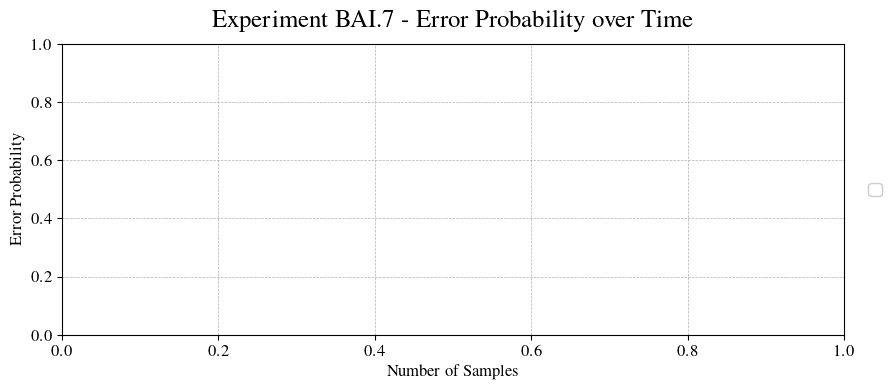

In [6]:
title = f'Experiment BAI.{expnum} - Error Probability over Time'
out_path = Path(f'results/BAI.{expnum}.pdf')
algos = ['Uniform', 'UCBE-2', 'UCBE-4', 'UCBE-8', 'UGapE-2', 'UGapE-4', 'UGapE-8', 'VarDE_lse-0.05', 'VarDE_lse-0.1', 'VarDE_lse-0.15']

plt.figure(figsize=(9, 4))
palette = sns.color_palette(palette, n_colors=len(algos))
ax = sns.lineplot(
    data=df_long[df_long['algorithm'].isin(algos)],
    x='step',
    y='error_prob',
    hue='algorithm',
    palette=palette,
    linewidth=2.0,
    alpha=1.0,
)

ax.set_title(title, pad=12)
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Error Probability')
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=1.0)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=1.0,
)

plt.tight_layout(rect=[0, 0, 1, 1])
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path)

In [ ]:
mpl.rcParams.update({
    "text.usetex": True,

    # IMPORTANT: let LaTeX decide the font (via preamble),
    # but keep matplotlib in serif mode
    "font.family": "serif",

    # Embed fonts as TrueType (selectable/searchable)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Sizes (optional but helps consistency)
    "axes.titlesize": 23,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
        
	# Force Times-like fonts in the LaTeX that matplotlib runs
    "text.latex.preamble": r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """,
})
palette = ["#1F77B4","#2CA02C","#6A3D9A","#D62728","#FF8C00"]

In [ ]:
title = f'Experiment BAI.{expnum} - Error Probability over Time'
out_path = Path(f'results/BAI.{expnum}.pdf')
algos = df_long['algorithm'].unique()

plt.figure(figsize=(9, 4))
ax = sns.lineplot(
    data=df_long,
    x='step',
    y='error_prob',
    hue='algorithm',
    palette=palette,
    linewidth=2.0,
    alpha=1.0,
)
ax.set_title(title, pad=12)
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Error Probability')
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=1.0)

ax.legend(loc='upper right', framealpha=1.0)

plt.tight_layout()
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path)